In [4]:
import pickle as pk
import numpy as np
import matplotlib.pyplot as pl
pl.rc('text', usetex=True)
%matplotlib inline
import os
import sys, os
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'
from jax.lib import xla_bridge
platform = xla_bridge.get_backend().platform
import jax
import jax.numpy as jnp
from jax import vmap, grad, pmap
print(jax.local_device_count(), jax.device_count())
jax.config.update('jax_platform_name', platform)
jax.config.update("jax_enable_x64", True)

import pathlib
curr_path = pathlib.Path().absolute()
abs_path_data = os.path.abspath(curr_path / "../../data/") 
abs_path_src = os.path.abspath(curr_path / "../../src/") 
abs_path_results = os.path.abspath(curr_path / "../../results/") 
abs_path_params = os.path.abspath(curr_path / "../../param_files/") 
sys.path.append((curr_path))
sys.path.append((abs_path_data))
sys.path.append((abs_path_results))
sys.path.append(abs_path_src)

from jax import config
import scipy.interpolate as interp
import pickle as pk
import numpy as np
import colossus 
import configobj

from base_class import base_class
from get_radial_profiles import Profiles
from get_Pkzs import get_Pkz
from get_Cls import get_Cl
from get_Xis import get_xi
from get_covs import get_cov





1 1


In [2]:
def get_samps(fname, param_acorr='sigma8', ess_thresh = 100, acorr_max = 0.075, acorr_min = 0.0075, nchains = 96):
    df = pk.load(open(fname,'rb'))
    sig8 = df['sigma8']
    
    sig8_rs = sig8.reshape(nchains,-1)
    # print(sig8_rs.shape)
    # from numpyro.diagnostics import autocorrelation, autocovariance
    
    # acorr = autocorrelation(sig8_rs, axis=1)
    # ind_del = []
    # for ji in range(acorr.shape[0]):
    #     if (np.std(acorr[ji,100:]) > acorr_max) or (np.std(acorr[ji,100:]) < acorr_min):
    #         ind_del.append(ji)    
    # print(len(ind_del))
    from numpyro.diagnostics import autocorrelation, autocovariance, effective_sample_size
    
    # acorr = autocorrelation(sig8_rs, axis=1)
    # ind_del = []
    # for ji in range(acorr.shape[0]):
    #     if (np.std(acorr[ji,100:]) > acorr_max) or (np.std(acorr[ji,100:]) < acorr_min):
    #         ind_del.append(ji)    

    ess_per_chain = effective_sample_size(jnp.asarray(sig8_rs))
    
    ind_del = []
    for jc in range(nchains):
        ess_jc = effective_sample_size(jnp.asarray(sig8_rs)[jc,:][None,:])
        if ess_jc < ess_thresh:
            ind_del.append(jc)      
    
    ind_del = np.array(ind_del)    

    
    samps = []
    keys = []
    for key in df:
        if ('base' not in key) and ('decentered' not in key):
            if key not in ['RUN_SETTINGS', 'diverging', 'potential_energy']:
            # if key not in ['prior_min', 'prior_max', 'fiducial_sims_params', 'fiducial_other_params', 'fiducial_halo_params', 'fiducial_analysis_params', 'diverging', 'potential_energy']:
                if ('Delta_z_bias_array' in key) or ('mult_shear_bias_array' in key):
                    for jb in range(4):
                        samps.append(df[key][:, jb])
                        keys.append(key + '_' + str(jb))
                        # print(df[key][:, jb].shape)
                # print(samps[0].shape)
                # print(df[key].shape)
                else:
                    samps.append(df[key])
                    keys.append(key)
    
    samps = np.array(samps).T
    ind_sigma8 = keys.index('sigma8')
    # ind_thetaejM = keys.index('nu_theta_ej_M')
    ind_Om = keys.index('Om0')
    samp_S8 = samps[:,ind_sigma8] * (samps[:,ind_Om]/0.3)**0.5
    
    samps = np.concatenate([samps, samp_S8[:,None]], axis=1)
    keys.append('S8')
    
    import getdist
    from getdist import plots, MCSamples
    
    names = keys    
    ind_frac_rm = 0.5
    # nchains = 80
    samps_sel = samps.reshape(nchains,-1, samps.shape[-1])
    nsamp_per_chain = samps_sel.shape[1]
    nrm = int(ind_frac_rm * nsamp_per_chain)
    samps_sel = samps_sel[:, nrm:, :]
    
    if len(ind_del) > 0:
        samps_sel = np.delete(samps_sel, ind_del, axis=0)
    else:
        samps_sel = samps_sel
    
    samps = samps_sel.reshape(-1, samps_sel.shape[-1])
    print(samps.shape, samps_sel.shape)
    return samps, keys




In [3]:
import yaml
from deepmerge import always_merger
from jax_cosmo import Cosmology
from jax_cosmo.background import angular_diameter_distance, radial_comoving_distance
from astropy import constants as const
import jax_cosmo.background as bkgrd

def get_dicts_default():
    
    def read_yaml(file_path):
        with open(file_path, 'r') as file:
            data = yaml.safe_load(file)
        return data
    
    def generate_dicts(data):
        sim_params_dict = data.get('sim_params', {})
        halo_params_dict = data.get('halo_params', {})
        analysis_dict = data.get('analysis', {})
        other_params_dict = data.get('other_params', {})
        return sim_params_dict, halo_params_dict, analysis_dict, other_params_dict
    
    default_data = read_yaml(abs_path_params + '/params_default.yaml')
    # sim_params_dict, halo_params_dict, analysis_dict, other_params_dict = generate_dicts(default_data)
    new_data = read_yaml(abs_path_params + '/Pge/params.yaml')
    # new_data = read_yaml(abs_path_params + '/DESxACT/params_v0.yaml')
    merged_data = always_merger.merge(default_data, new_data)
    
    sim_params_dict, halo_params_dict, analysis_dict, other_params_dict = generate_dicts(merged_data)
    
    # analysis_dict['beam_fwhm_arcmin'] = 1.4
    df_nz_comoving = np.loadtxt(abs_path_data + '/pge/comoving_nz_bgs_lrg_DESIY3_key_zall.txt')
    zarray_comoving = df_nz_comoving[:,0]
    nz_comoving_orig = df_nz_comoving[:,1]
    indsel = np.where(zarray_comoving < 0.4)[0]
    nz_comoving = np.zeros_like(zarray_comoving)
    nz_comoving[indsel] = nz_comoving_orig[indsel]*1.0
    indsel = np.where(zarray_comoving > 0.4)[0]
    nz_comoving[indsel] = nz_comoving_orig[indsel]*1.0
    analysis_dict['nbar_gal_comoving_zarray'] = zarray_comoving
    analysis_dict['nbar_gal_comoving_val'] = nz_comoving
    
    
    
    from scipy.interpolate import interp1d
    # ks = np.geomspace(5e-2,50,15) # wavenumbers
    ks = np.geomspace(3e-1,10,10) # wavenumbers
    zedges = np.array([0.1, 0.4, 0.6, 0.8,1.1])
    zarray_lens = np.linspace(0.001, 1.6, 100)
    nbins_lens = len(zedges) - 1
    
    cosmo_params = sim_params_dict.get('cosmo')
    cosmo_jax = Cosmology(
                Omega_c=cosmo_params['Om0'] - cosmo_params['Ob0'],
                Omega_b=cosmo_params['Ob0'],
                h=cosmo_params['H0'] / 100.,
                sigma8=cosmo_params['sigma8'],
                n_s=cosmo_params['ns'],
                Omega_k=0.,
                w0=cosmo_params['w0'],
                wa=0.
                )
    scale_fac_a_array = 1.0 / (1.0 + zarray_lens)
    chi_array = radial_comoving_distance(cosmo_jax, scale_fac_a_array)
    dchi_dz_array = (const.c.value * 1e-3) / bkgrd.H(cosmo_jax, scale_fac_a_array)
    nz_comoving_interp = interp1d(zarray_comoving, nz_comoving, fill_value=1e-20, bounds_error=False)
    nz_comoving_zarray = nz_comoving_interp(zarray_lens)
    nz_zarray = nz_comoving_zarray * (chi_array**2 * dchi_dz_array)
    nz_zarray = nz_zarray/(np.trapz(nz_zarray, zarray_lens))
    nz_lens = {}
    for jb in range(nbins_lens):
        nz_jb = np.zeros_like(nz_zarray)
        indsel = np.where((zarray_lens > zedges[jb]) & (zarray_lens < zedges[jb+1]))[0]
        nz_jb[indsel] = nz_zarray[indsel]
        norm_val = np.trapz(nz_jb, zarray_lens)
        nz_jb = nz_jb/norm_val
        nz_lens[jb] = nz_jb
    
    nz_info_dict = {}
    nz_info_dict['z_array_lens'] = zarray_lens
    nz_info_dict['nbins_lens'] = nbins_lens
    for ji in range(nz_info_dict['nbins_lens']):
        nz_info_dict['nz'+str(ji)] = np.maximum(nz_lens[ji], 1e-3)
    analysis_dict['nz_lens_info_dict'] = nz_info_dict
    
    
    from astropy.io import fits
    df = fits.open(os.path.abspath(abs_path_data + '/forecast/lsst_simulate_Y1.fits'))
    z_array = df['nz_source'].data['Z_MID']
    nz_info_dict = {}
    nz_info_dict['z_array_source'] = z_array
    nz_info_dict['nbins'] = 5
    for ji in range(nz_info_dict['nbins']):
        nz_info_dict['nz'+str(ji)] = np.maximum(df['nz_source'].data['BIN'+str(ji+1)], 1e-4)
    analysis_dict['nz_source_info_dict'] = nz_info_dict
    other_params_dict['Delta_z_bias_array'] = np.zeros(analysis_dict['nz_source_info_dict']['nbins'])
    other_params_dict['mult_shear_bias_array'] = np.zeros(analysis_dict['nz_source_info_dict']['nbins'])
    
    
    analysis_dict['angles_data_array'] = df['xip'].data['ANG'][0:20]
    
    
    analysis_dict['k_array_survey'] = jnp.array(ks / (sim_params_dict['cosmo']['H0']/100.))
    
    lmin, lmax, dl_log_array = 80.0, 8800.0, 0.23025851
    l_array_all = np.exp(np.arange(np.log(lmin), np.log(lmax), dl_log_array))
    dl_array = l_array_all[1:] - l_array_all[:-1]
    l_array_survey = (l_array_all[1:] + l_array_all[:-1]) / 2.
    halo_params_dict['ell_array'] = jnp.array(l_array_survey)
    analysis_dict['l_array_survey'] = jnp.array(l_array_survey)
    analysis_dict['dl_array_survey'] = jnp.array(dl_array)
    analysis_dict['yy_noise_ell_fname'] = os.path.abspath(abs_path_data + '/pge/Noise_fid_yy_beamed_1p4arcmin.txt')
    
    Ngals_bins = []
    Vol_Gpc3 = []
    z_cens = []
    P0 = 9e3
    fsky_DESIxDESI = analysis_dict['fsky_gg']
    for jb in range(nbins_lens):
        nz_jb_only = np.copy(nz_comoving_zarray)
        indsel = np.where((zarray_lens < zedges[jb]) | (zarray_lens > zedges[jb+1]))[0]
        nz_jb_only[indsel] = 0.0
        nz_integrate = np.trapz(nz_jb_only*(chi_array**2)*dchi_dz_array, zarray_lens)
    
        ntot_jb = nz_integrate*4*np.pi*fsky_DESIxDESI
        Ngals_bins.append(ntot_jb)
    
        zmean = np.trapz(zarray_lens*nz_jb_only*(chi_array**2)*dchi_dz_array, zarray_lens)/nz_integrate
        z_cens.append(zmean)
    
        fsky_nz = np.ones_like(zarray_lens)
        fsky_nz[indsel] = 0.0
        fsky_nz_desi = fsky_nz * (nz_jb_only*P0/(1 + nz_jb_only*P0))**2
        h3 = (sim_params_dict['cosmo']['H0'] / 100.0)**3
        Vol_Gpc3_comoving = 4*np.pi*fsky_DESIxDESI*np.trapz(fsky_nz * (chi_array**2)*dchi_dz_array, zarray_lens)/(h3 * 1e9)   
        Vol_Gpc3_comoving_desi = 4*np.pi*fsky_DESIxDESI*np.trapz(fsky_nz_desi * (chi_array**2)*dchi_dz_array, zarray_lens)/(h3 * 1e9)   
    
        Vol_Gpc3.append(Vol_Gpc3_comoving_desi)
        # print(zedges[jb], zedges[jb+1], 'Total galaxies = {:.2f}'.format(ntot_jb), ' Vol:', Vol_Gpc3_comoving_desi)
        # print('Bin {}: Total galaxies = {:.2f}'.format(jb, ntot_jb))
        
    
    Ngals_bins, Vol_Gpc3, z_cens = np.array(Ngals_bins), np.array(Vol_Gpc3), np.array(z_cens)
        
        # Ngals_bins = 3.33*np.array([506905, 771875, 859824])
    analysis_dict['nbar_lens_bins'] = Ngals_bins/(analysis_dict['fsky_gg']*41253*(60**2))
    
    analysis_dict['symbolic_pk'] = True
    analysis_dict['symbolic_hmf'] = True

    return sim_params_dict, halo_params_dict, analysis_dict, other_params_dict



In [4]:
save_chain_dir = abs_path_results + '/pge/chains_july_v5/'
# probe = 'xip_xim'
# probe = 'ky_kk_gg_gy_gk_ge'
# probes_forecast_all_str = 'ky_kk_gg_gy_gk_ge'
probes_forecast_all_str = 'kk_gg_gk_ge'
sc_val = 4000
num_warmup = 3000
num_samples = 4000
num_chains= 24
n_parallel = 4
max_tree_depth = 4
wbao_prior = False
# init_strategy = 


if wbao_prior:
    savefname_out = save_chain_dir + f'{probes_forecast_all_str}/mcmc_v5_{probes_forecast_all_str}_scval_{sc_val}_samples_{num_samples}_warmup_{num_warmup}_num_chains_{num_chains*n_parallel}_treedepth_{max_tree_depth}_wbaoprior_{wbao_prior}.pkl'
else:
    savefname_out = save_chain_dir + f'{probes_forecast_all_str}/mcmc_v5_{probes_forecast_all_str}_scval_{sc_val}_samples_{num_samples}_warmup_{num_warmup}_num_chains_{num_chains*n_parallel}_treedepth_{max_tree_depth}.pkl'


samps, keys = get_samps(savefname_out)

nsamp_tot = samps.shape[0]
indsel = np.sort(np.random.randint(0, nsamp_tot, 32))
# indsel = np.sort(np.random.randint(0, nsamp_tot, 8))
# indsel = np.sort(np.random.randint(0, nsamp_tot, 512))




(26000, 29) (13, 2000, 29)


In [5]:
import warnings
warnings.filterwarnings('ignore')



In [6]:
from tqdm import tqdm

# ind_post = keys.index('potential_energy')
# post = -1.* samps[:,ind_post]

# map_ind = np.where(post == post.max())[0][0]

# Y_model_all_samp = []
Pmm_ratio_all_samp = []

for map_ind in tqdm(indsel):
    saved_bestfit = {}
    for jk, key in enumerate(keys):
        # print(key, samps[map_ind, jk])
        saved_bestfit[key] = samps[map_ind, jk]
    
    # potential_energy -4916.635080802822
    import yaml
    import pathlib
    curr_path = pathlib.Path().absolute()
    abs_path_data = os.path.abspath(curr_path / "../../data/") 
    abs_path_src = os.path.abspath(curr_path / "../../src/") 
    abs_path_results = os.path.abspath(curr_path / "../../results/") 
    abs_path_params = os.path.abspath(curr_path / "../../param_files/") 
    

    sim_params_dict, halo_params_dict, analysis_dict, other_params_dict = get_dicts_default()
    
    
    for key in saved_bestfit.keys():
        if key in list(sim_params_dict.keys()):
            sim_params_dict[key] = float(saved_bestfit[key])
        if key in list(sim_params_dict['cosmo'].keys()):
            sim_params_dict['cosmo'][key] = float(saved_bestfit[key])
            if key == 'h':
                sim_params_dict['cosmo']['H0'] = 100*saved_bestfit[key]
        if key in list(other_params_dict.keys()):
            other_params_dict[key] = float(saved_bestfit[key])
    for jb in range(analysis_dict['nz_source_info_dict']['nbins'] - 1):
        other_params_dict['Delta_z_bias_array'][jb] = saved_bestfit[f'Delta_z_bias_array_{jb}']
    for jb in range(analysis_dict['nz_source_info_dict']['nbins'] - 1):
        other_params_dict['mult_shear_bias_array'][jb] = saved_bestfit[f'mult_shear_bias_array_{jb}']

    # halo_params_dict['rmax'] = 12.0
    # halo_params_dict['nr'] = 128
    # halo_params_dict['nk'] = 96
    base_test = base_class(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict)
    profiles_test = Profiles(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, base_class_obj=base_test)
    Pkz_test = get_Pkz(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, Profiles_obj=profiles_test)
    ratio = Pkz_test.Pmm_dmb_tot_mat[:,0]/Pkz_test.Pmm_nfw_tot_mat[:,0]    
    # Pmm_ratio_all_samp.append(savitzky_golay(ratio, 19, 3))
    # print(ratio)
    Pmm_ratio_all_samp.append(ratio)




100%|██████████| 32/32 [05:25<00:00, 10.18s/it]


In [7]:
Pmm_ratio_all_samp = np.array(Pmm_ratio_all_samp)
# Pmm_ratio_all_samp_mean = np.mean(Pmm_ratio_all_samp, axis=0)
# Pmm_ratio_all_samp_std = np.std(Pmm_ratio_all_samp, axis=0)
Pmin = np.percentile(Pmm_ratio_all_samp, 16, axis=0)
Pmax = np.percentile(Pmm_ratio_all_samp, 84, axis=0)




In [8]:
import matplotlib.pyplot as plt
%matplotlib inline



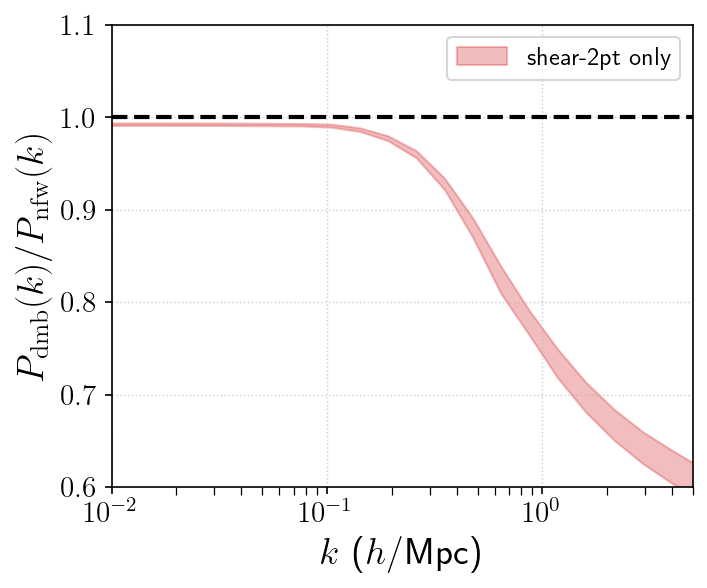

In [9]:
import matplotlib.pyplot as plt

# plt.figure(figsize=(7, 5), dpi=150)
plt.figure(figsize=(5, 4), dpi=150)

# Fill between with transparency for uncertainty
plt.fill_between(Pkz_test.kPk_array, Pmin, Pmax, color='tab:red', alpha=0.3, label='shear-2pt only')
# plt.fill_between(Pkz_test.kPk_array, Pmin_all, Pmax_all, color='tab:gray', alpha=0.5, label=r'shear-2pt + shear $\times$ tSZ')
# pl.plot(pksup_owls[:,0], pksup_owls[:,1], color='g', ls='--', label='OWLS-AGN')
# pl.plot(pksup_mtng[:,0], pksup_mtng[:,1], color='b', label='MTNG')
# pl.plot(pksup_flamingo[:,0], pksup_flamingo[:,1], color='brown', label='FLAMINGO')
# Add horizontal reference line
plt.axhline(1.0, ls='--', lw=2, color='black')

# Log scale for x-axis
plt.xscale('log')

# Axis limits
plt.xlim(1e-2, 5)
plt.ylim(0.6, 1.1)

# Axis labels with LaTeX-style formatting
plt.xlabel(r'$k$ ($h$/Mpc)', fontsize=18)
plt.ylabel(r'$P_{\rm dmb}(k)/P_{\rm nfw}(k)$', fontsize=18)

# Improved tick formatting
plt.tick_params(axis='both', which='major', labelsize=14)
plt.tick_params(axis='both', which='minor', labelsize=12, length=4)

plt.legend(fontsize=12, frameon=True, loc='best')
# Grid for better readability
# plt.grid(True, which="both", linestyle=":", linewidth=0.7, alpha=0.6)
plt.grid(True, linestyle=":", linewidth=0.7, alpha=0.6)

# Save figure with high quality (Uncomment if needed)
sdir = '/projects/bdne/spandey3/new_godmax/GODMAX/results/DESxACT/plots/'
# plt.savefig(sdir + 'DeltaP_P_v10_widemuej.pdf', bbox_inches='tight', dpi=300 )
plt.show()




In [5]:
import sys, os
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'
from jax.lib import xla_bridge
platform = xla_bridge.get_backend().platform
import jax
import jax.numpy as jnp
from jax import vmap, grad, pmap
print(jax.local_device_count(), jax.device_count())
jax.config.update('jax_platform_name', platform)
jax.config.update("jax_enable_x64", True)

import pathlib
curr_path = pathlib.Path().absolute()
abs_path_data = os.path.abspath(curr_path / "../../data/") 
abs_path_src = os.path.abspath(curr_path / "../../src/") 
abs_path_results = os.path.abspath(curr_path / "../../results/") 
abs_path_params = os.path.abspath(curr_path / "../../param_files/") 
sys.path.append((curr_path))
sys.path.append((abs_path_data))
sys.path.append((abs_path_results))
sys.path.append(abs_path_src)

import numpyro
numpyro.set_platform("gpu")
numpyro.enable_x64()
numpyro.set_host_device_count(jax.device_count())
from numpyro.handlers import seed, trace, condition
from numpyro.infer.reparam import LocScaleReparam, TransformReparam
from numpyro.infer import HMC, HMCECS, MCMC, NUTS, SA, SVI, Trace_ELBO, init_to_value
from numpyro.distributions.transforms import AffineTransform
import numpyro.distributions as dist

from jax import config
import scipy.interpolate as interp
import pickle as pk
import numpy as np
import colossus 
import configobj
import copy
import yaml
from deepmerge import always_merger
import ast 

from base_class import base_class
from get_radial_profiles import Profiles
from get_Pkzs import get_Pkz
from get_Cls import get_Cl
from get_Xis import get_xi
from get_covs import get_cov

import jax_cosmo.background as bkgrd
from jax_cosmo import Cosmology
from jax_cosmo.background import angular_diameter_distance, radial_comoving_distance
from astropy import constants as const
from numpyro.diagnostics import autocorrelation, autocovariance, effective_sample_size
import yaml
from deepmerge import always_merger
from jax_cosmo import Cosmology
from jax_cosmo.background import angular_diameter_distance, radial_comoving_distance
from astropy import constants as const
import jax_cosmo.background as bkgrd
import getdist
from getdist import plots, MCSamples
from tqdm import tqdm
import ast
import argparse
from scipy.interpolate import interp1d
import astropy.units as u
from astropy import constants as const


def get_samps(fname, param_acorr='sigma8', ess_thresh = 100, acorr_max = 0.075, acorr_min = 0.0075, nchains = 96):
    df = pk.load(open(fname,'rb'))
    sig8 = df[param_acorr]
    
    sig8_rs = sig8.reshape(nchains,-1)
        
    ind_del = []
    for jc in range(nchains):
        ess_jc = effective_sample_size(jnp.asarray(sig8_rs)[jc,:][None,:])
        if ess_jc < ess_thresh:
            ind_del.append(jc)      
    
    ind_del = np.array(ind_del)    

    
    samps = []
    keys = []
    for key in df:
        if ('base' not in key) and ('decentered' not in key):
            if key not in ['RUN_SETTINGS', 'diverging', 'potential_energy']:
            # if key not in ['prior_min', 'prior_max', 'fiducial_sims_params', 'fiducial_other_params', 'fiducial_halo_params', 'fiducial_analysis_params', 'diverging', 'potential_energy']:
                if ('Delta_z_bias_array' in key) or ('mult_shear_bias_array' in key):
                    for jb in range(4):
                        samps.append(df[key][:, jb])
                        keys.append(key + '_' + str(jb))
                        # print(df[key][:, jb].shape)
                # print(samps[0].shape)
                # print(df[key].shape)
                else:
                    samps.append(df[key])
                    keys.append(key)
    
    samps = np.array(samps).T
    ind_sigma8 = keys.index('sigma8')
    # ind_thetaejM = keys.index('nu_theta_ej_M')
    ind_Om = keys.index('Om0')
    samp_S8 = samps[:,ind_sigma8] * (samps[:,ind_Om]/0.3)**0.5
    
    samps = np.concatenate([samps, samp_S8[:,None]], axis=1)
    keys.append('S8')
    
    
    names = keys    
    ind_frac_rm = 0.5
    # nchains = 80
    samps_sel = samps.reshape(nchains,-1, samps.shape[-1])
    nsamp_per_chain = samps_sel.shape[1]
    nrm = int(ind_frac_rm * nsamp_per_chain)
    samps_sel = samps_sel[:, nrm:, :]
    
    if len(ind_del) > 0:
        samps_sel = np.delete(samps_sel, ind_del, axis=0)
    else:
        samps_sel = samps_sel
    
    samps = samps_sel.reshape(-1, samps_sel.shape[-1])
    print(samps.shape, samps_sel.shape)
    return samps, keys


def get_dicts_default():
    
    def read_yaml(file_path):
        with open(file_path, 'r') as file:
            data = yaml.safe_load(file)
        return data
    
    def generate_dicts(data):
        sim_params_dict = data.get('sim_params', {})
        halo_params_dict = data.get('halo_params', {})
        analysis_dict = data.get('analysis', {})
        other_params_dict = data.get('other_params', {})
        return sim_params_dict, halo_params_dict, analysis_dict, other_params_dict
    
    default_data = read_yaml(abs_path_params + '/params_default.yaml')
    # sim_params_dict, halo_params_dict, analysis_dict, other_params_dict = generate_dicts(default_data)
    new_data = read_yaml(abs_path_params + '/Pge/params.yaml')
    # new_data = read_yaml(abs_path_params + '/DESxACT/params_v0.yaml')
    merged_data = always_merger.merge(default_data, new_data)
    
    sim_params_dict, halo_params_dict, analysis_dict, other_params_dict = generate_dicts(merged_data)
    
    # analysis_dict['beam_fwhm_arcmin'] = 1.4
    df_nz_comoving = np.loadtxt(abs_path_data + '/pge/comoving_nz_bgs_lrg_DESIY3_key_zall.txt')
    zarray_comoving = df_nz_comoving[:,0]
    nz_comoving_orig = df_nz_comoving[:,1]
    indsel = np.where(zarray_comoving < 0.4)[0]
    nz_comoving = np.zeros_like(zarray_comoving)
    nz_comoving[indsel] = nz_comoving_orig[indsel]*1.0
    indsel = np.where(zarray_comoving > 0.4)[0]
    nz_comoving[indsel] = nz_comoving_orig[indsel]*1.0
    analysis_dict['nbar_gal_comoving_zarray'] = zarray_comoving
    analysis_dict['nbar_gal_comoving_val'] = nz_comoving
    
    
    
    from scipy.interpolate import interp1d
    # ks = np.geomspace(5e-2,50,15) # wavenumbers
    ks = np.geomspace(3e-1,10,10) # wavenumbers
    zedges = np.array([0.1, 0.4, 0.6, 0.8,1.1])
    zarray_lens = np.linspace(0.001, 1.6, 100)
    nbins_lens = len(zedges) - 1
    
    cosmo_params = sim_params_dict.get('cosmo')
    cosmo_jax = Cosmology(
                Omega_c=cosmo_params['Om0'] - cosmo_params['Ob0'],
                Omega_b=cosmo_params['Ob0'],
                h=cosmo_params['H0'] / 100.,
                sigma8=cosmo_params['sigma8'],
                n_s=cosmo_params['ns'],
                Omega_k=0.,
                w0=cosmo_params['w0'],
                wa=0.
                )
    scale_fac_a_array = 1.0 / (1.0 + zarray_lens)
    chi_array = radial_comoving_distance(cosmo_jax, scale_fac_a_array)
    dchi_dz_array = (const.c.value * 1e-3) / bkgrd.H(cosmo_jax, scale_fac_a_array)
    nz_comoving_interp = interp1d(zarray_comoving, nz_comoving, fill_value=1e-20, bounds_error=False)
    nz_comoving_zarray = nz_comoving_interp(zarray_lens)
    nz_zarray = nz_comoving_zarray * (chi_array**2 * dchi_dz_array)
    nz_zarray = nz_zarray/(np.trapz(nz_zarray, zarray_lens))
    nz_lens = {}
    for jb in range(nbins_lens):
        nz_jb = np.zeros_like(nz_zarray)
        indsel = np.where((zarray_lens > zedges[jb]) & (zarray_lens < zedges[jb+1]))[0]
        nz_jb[indsel] = nz_zarray[indsel]
        norm_val = np.trapz(nz_jb, zarray_lens)
        nz_jb = nz_jb/norm_val
        nz_lens[jb] = nz_jb
    
    nz_info_dict = {}
    nz_info_dict['z_array_lens'] = zarray_lens
    nz_info_dict['nbins_lens'] = nbins_lens
    for ji in range(nz_info_dict['nbins_lens']):
        nz_info_dict['nz'+str(ji)] = np.maximum(nz_lens[ji], 1e-3)
    analysis_dict['nz_lens_info_dict'] = nz_info_dict
    
    
    from astropy.io import fits
    df = fits.open(os.path.abspath(abs_path_data + '/forecast/lsst_simulate_Y1.fits'))
    z_array = df['nz_source'].data['Z_MID']
    nz_info_dict = {}
    nz_info_dict['z_array_source'] = z_array
    nz_info_dict['nbins'] = 5
    for ji in range(nz_info_dict['nbins']):
        nz_info_dict['nz'+str(ji)] = np.maximum(df['nz_source'].data['BIN'+str(ji+1)], 1e-4)
    analysis_dict['nz_source_info_dict'] = nz_info_dict
    other_params_dict['Delta_z_bias_array'] = np.zeros(analysis_dict['nz_source_info_dict']['nbins'])
    other_params_dict['mult_shear_bias_array'] = np.zeros(analysis_dict['nz_source_info_dict']['nbins'])
    
    
    analysis_dict['angles_data_array'] = df['xip'].data['ANG'][0:20]
    
    
    analysis_dict['k_array_survey'] = jnp.array(ks / (sim_params_dict['cosmo']['H0']/100.))
    
    lmin, lmax, dl_log_array = 80.0, 8800.0, 0.23025851
    l_array_all = np.exp(np.arange(np.log(lmin), np.log(lmax), dl_log_array))
    dl_array = l_array_all[1:] - l_array_all[:-1]
    l_array_survey = (l_array_all[1:] + l_array_all[:-1]) / 2.
    halo_params_dict['ell_array'] = jnp.array(l_array_survey)
    analysis_dict['l_array_survey'] = jnp.array(l_array_survey)
    analysis_dict['dl_array_survey'] = jnp.array(dl_array)
    analysis_dict['yy_noise_ell_fname'] = os.path.abspath(abs_path_data + '/pge/Noise_fid_yy_beamed_1p4arcmin.txt')
    
    Ngals_bins = []
    Vol_Gpc3 = []
    z_cens = []
    P0 = 9e3
    fsky_DESIxDESI = analysis_dict['fsky_gg']
    for jb in range(nbins_lens):
        nz_jb_only = np.copy(nz_comoving_zarray)
        indsel = np.where((zarray_lens < zedges[jb]) | (zarray_lens > zedges[jb+1]))[0]
        nz_jb_only[indsel] = 0.0
        nz_integrate = np.trapz(nz_jb_only*(chi_array**2)*dchi_dz_array, zarray_lens)
    
        ntot_jb = nz_integrate*4*np.pi*fsky_DESIxDESI
        Ngals_bins.append(ntot_jb)
    
        zmean = np.trapz(zarray_lens*nz_jb_only*(chi_array**2)*dchi_dz_array, zarray_lens)/nz_integrate
        z_cens.append(zmean)
    
        fsky_nz = np.ones_like(zarray_lens)
        fsky_nz[indsel] = 0.0
        fsky_nz_desi = fsky_nz * (nz_jb_only*P0/(1 + nz_jb_only*P0))**2
        h3 = (sim_params_dict['cosmo']['H0'] / 100.0)**3
        Vol_Gpc3_comoving = 4*np.pi*fsky_DESIxDESI*np.trapz(fsky_nz * (chi_array**2)*dchi_dz_array, zarray_lens)/(h3 * 1e9)   
        Vol_Gpc3_comoving_desi = 4*np.pi*fsky_DESIxDESI*np.trapz(fsky_nz_desi * (chi_array**2)*dchi_dz_array, zarray_lens)/(h3 * 1e9)   
    
        Vol_Gpc3.append(Vol_Gpc3_comoving_desi)
        # print(zedges[jb], zedges[jb+1], 'Total galaxies = {:.2f}'.format(ntot_jb), ' Vol:', Vol_Gpc3_comoving_desi)
        # print('Bin {}: Total galaxies = {:.2f}'.format(jb, ntot_jb))
        
    
    Ngals_bins, Vol_Gpc3, z_cens = np.array(Ngals_bins), np.array(Vol_Gpc3), np.array(z_cens)
        
        # Ngals_bins = 3.33*np.array([506905, 771875, 859824])
    analysis_dict['nbar_lens_bins'] = Ngals_bins/(analysis_dict['fsky_gg']*41253*(60**2))
    
    analysis_dict['symbolic_pk'] = True
    analysis_dict['symbolic_hmf'] = True

    return sim_params_dict, halo_params_dict, analysis_dict, other_params_dict




1 1


In [6]:
import yaml
import pathlib
curr_path = pathlib.Path().absolute()
abs_path_data = os.path.abspath(curr_path / "../../data/") 
abs_path_src = os.path.abspath(curr_path / "../../src/") 
abs_path_results = os.path.abspath(curr_path / "../../results/") 
abs_path_params = os.path.abspath(curr_path / "../../param_files/") 


sim_params_dict, halo_params_dict, analysis_dict, other_params_dict = get_dicts_default()
base_test = base_class(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict)
profiles_test = Profiles(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, base_class_obj=base_test)
Pkz_test = get_Pkz(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, Profiles_obj=profiles_test)
Pmm_ratio_fid = Pkz_test.Pmm_dmb_tot_mat[:,0]/Pkz_test.Pmm_nfw_tot_mat[:,0]    

h = sim_params_dict['cosmo']['H0'] / 100.0
Ob = sim_params_dict['cosmo']['Ob0']
Om = sim_params_dict['cosmo']['Om0']
sigmat = const.sigma_T
m_e = const.m_e
c = const.c
coeff = sigmat / (m_e * (c ** 2))
oneMpc_h_to_cm = (((10 ** 6)/h) * (u.pc).to(u.cm))
const_coeff = ((coeff).to(((u.kpc ** 2) / u.keV))).value
indz = 0
M_array = profiles_test.M_array
rho_baryon_mat = profiles_test.rho_gas_mat + profiles_test.rho_cga_mat + ((profiles_test.fstar_sat_mat/profiles_test.fclm_mat)[None,:,:])*profiles_test.rho_clm_mat
rho_tot_mat = profiles_test.rho_dmb_mat
rho_baryon_mat_z0 = rho_baryon_mat[:,indz,:]
rho_tot_mat_z0 = rho_tot_mat[:,indz,:]


Y_model_fid = np.zeros(len(M_array))
fb_model_fid = np.zeros(len(M_array))
for jM in range(len(M_array)):
    Mj = M_array[jM]
    r200_jM = profiles_test.r200c_mat[indz, jM]    
    r_array_jM = np.logspace(-3, np.log10(r200_jM), 100)
    Pe_jz_jM = profiles_test.Pe_mat_physical[:, indz, jM]
    interpPe = interp1d(np.log(profiles_test.r_array), np.log(Pe_jz_jM), fill_value='extrapolate')
    Pe_jM = np.exp(interpPe(np.log(r_array_jM)))
    Y_jM = np.trapz(4 * np.pi * r_array_jM**3 * Pe_jM, np.log(r_array_jM))
    Y_model_fid[jM] = const_coeff * Y_jM * (oneMpc_h_to_cm**3)

    rho_baryon_jM = rho_baryon_mat_z0[:,jM]
    interprho = interp1d(np.log(profiles_test.r_array), np.log(rho_baryon_jM), fill_value='extrapolate')
    rhob_jM = np.exp(interprho(np.log(r_array_jM)))
    rhob_int_jM = np.trapezoid(4 * np.pi * r_array_jM**3 * rhob_jM, np.log(r_array_jM))


    rho_tot_jM = rho_tot_mat_z0[:,jM]
    interprho = interp1d(np.log(profiles_test.r_array), np.log(rho_tot_jM), fill_value='extrapolate')
    rhotot_jM = np.exp(interprho(np.log(r_array_jM)))
    rhotot_int_jM = np.trapezoid(4 * np.pi * r_array_jM**3 * rhotot_jM, np.log(r_array_jM))

    fb_model_fid[jM] = rhob_int_jM/rhotot_int_jM




/tmp/ipykernel_1738352/3363385396.py:192: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  nz_zarray = nz_zarray/(np.trapz(nz_zarray, zarray_lens))
/tmp/ipykernel_1738352/3363385396.py:198: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  norm_val = np.trapz(nz_jb, zarray_lens)
/tmp/ipykernel_1738352/3363385396.py:246: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  nz_integrate = np.trapz(nz_jb_only*(chi_array**2)*dchi_dz_array, zarray_lens)
/tmp/ipykernel_1738352/3363385396.py:251: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  zmean = np.trapz(zarray_lens*nz_jb_only*(chi_array**2)*dchi_dz_array, zarray_lens)/nz_integrate
/tmp/ipyk

In [22]:
save_chain_dir = abs_path_results + '/pge/chains_july_v5/'
# probe = 'xip_xim'
# probe = 'ky_kk_gg_gy_gk_ge'
# probes_forecast_all_str = 'ky_kk_gg_gy_gk_ge'
probes_forecast_all_str = 'kk_gg_gk_ge'
sc_val = 4000
num_warmup = 3000
num_samples = 4000
num_chains= 24
n_parallel = 4
max_tree_depth = 4
wbao_prior = False
# init_strategy = 


if wbao_prior:
    savefname_out = save_chain_dir + f'{probes_forecast_all_str}/mcmc_v5_{probes_forecast_all_str}_scval_{sc_val}_samples_{num_samples}_warmup_{num_warmup}_num_chains_{num_chains*n_parallel}_treedepth_{max_tree_depth}_wbaoprior_{wbao_prior}.pkl'
else:
    savefname_out = save_chain_dir + f'{probes_forecast_all_str}/mcmc_v5_{probes_forecast_all_str}_scval_{sc_val}_samples_{num_samples}_warmup_{num_warmup}_num_chains_{num_chains*n_parallel}_treedepth_{max_tree_depth}.pkl'


samps, keys = get_samps(savefname_out)

nsamp_tot = samps.shape[0]
indsel = np.sort(np.random.randint(0, nsamp_tot, 128))
# indsel = np.sort(np.random.randint(0, nsamp_tot, 8))
# indsel = np.sort(np.random.randint(0, nsamp_tot, 512))




(26000, 29) (13, 2000, 29)


In [24]:
from tqdm import tqdm
import ast
import argparse
from scipy.interpolate import interp1d
import astropy.units as u
from astropy import constants as const


Y_M_model_all_samp = []
fb_M_model_all_samp = []
Pmm_ratio_all_samp = []

for map_ind in tqdm(indsel):
    saved_bestfit = {}
    for jk, key in enumerate(keys):
        # print(key, samps[map_ind, jk])
        saved_bestfit[key] = samps[map_ind, jk]
    
    import yaml
    import pathlib
    curr_path = pathlib.Path().absolute()
    abs_path_data = os.path.abspath(curr_path / "../../data/") 
    abs_path_src = os.path.abspath(curr_path / "../../src/") 
    abs_path_results = os.path.abspath(curr_path / "../../results/") 
    abs_path_params = os.path.abspath(curr_path / "../../param_files/") 
    

    sim_params_dict, halo_params_dict, analysis_dict, other_params_dict = get_dicts_default()
    
    
    for key in saved_bestfit.keys():
        if key in list(sim_params_dict.keys()):
            sim_params_dict[key] = float(saved_bestfit[key])
        if key in list(sim_params_dict['cosmo'].keys()):
            sim_params_dict['cosmo'][key] = float(saved_bestfit[key])
            if key == 'h':
                sim_params_dict['cosmo']['H0'] = 100*saved_bestfit[key]
        if key in list(other_params_dict.keys()):
            other_params_dict[key] = float(saved_bestfit[key])
    for jb in range(analysis_dict['nz_source_info_dict']['nbins'] - 1):
        other_params_dict['Delta_z_bias_array'][jb] = saved_bestfit[f'Delta_z_bias_array_{jb}']
    for jb in range(analysis_dict['nz_source_info_dict']['nbins'] - 1):
        other_params_dict['mult_shear_bias_array'][jb] = saved_bestfit[f'mult_shear_bias_array_{jb}']

    base_test = base_class(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict)
    profiles_test = Profiles(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, base_class_obj=base_test)
    Pkz_test = get_Pkz(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, Profiles_obj=profiles_test)
    ratio = Pkz_test.Pmm_dmb_tot_mat[:,0]/Pkz_test.Pmm_nfw_tot_mat[:,0]    
    Pmm_ratio_all_samp.append(ratio)

    h = sim_params_dict['cosmo']['H0'] / 100.0
    Ob = sim_params_dict['cosmo']['Ob0']
    Om = sim_params_dict['cosmo']['Om0']
    sigmat = const.sigma_T
    m_e = const.m_e
    c = const.c
    coeff = sigmat / (m_e * (c ** 2))
    oneMpc_h_to_cm = (((10 ** 6)/h) * (u.pc).to(u.cm))
    const_coeff = ((coeff).to(((u.kpc ** 2) / u.keV))).value
    indz = 0
    M_array = profiles_test.M_array
    rho_baryon_mat = profiles_test.rho_gas_mat + profiles_test.rho_cga_mat + ((profiles_test.fstar_sat_mat/profiles_test.fclm_mat)[None,:,:])*profiles_test.rho_clm_mat
    rho_tot_mat = profiles_test.rho_dmb_mat
    rho_baryon_mat_z0 = rho_baryon_mat[:,indz,:]
    rho_tot_mat_z0 = rho_tot_mat[:,indz,:]


    Y_model_all = np.zeros(len(M_array))
    fb_model_all = np.zeros(len(M_array))
    for jM in range(len(M_array)):
        Mj = M_array[jM]
        r200_jM = profiles_test.r200c_mat[indz, jM]    
        r_array_jM = np.logspace(-3, np.log10(r200_jM), 100)
        Pe_jz_jM = profiles_test.Pe_mat_physical[:, indz, jM]
        interpPe = interp1d(np.log(profiles_test.r_array), np.log(Pe_jz_jM), fill_value='extrapolate')
        Pe_jM = np.exp(interpPe(np.log(r_array_jM)))
        Y_jM = np.trapz(4 * np.pi * r_array_jM**3 * Pe_jM, np.log(r_array_jM))
        Y_model_all[jM] = const_coeff * Y_jM * (oneMpc_h_to_cm**3)

        rho_baryon_jM = rho_baryon_mat_z0[:,jM]
        interprho = interp1d(np.log(profiles_test.r_array), np.log(rho_baryon_jM), fill_value='extrapolate')
        rhob_jM = np.exp(interprho(np.log(r_array_jM)))
        rhob_int_jM = np.trapezoid(4 * np.pi * r_array_jM**3 * rhob_jM, np.log(r_array_jM))


        rho_tot_jM = rho_tot_mat_z0[:,jM]
        interprho = interp1d(np.log(profiles_test.r_array), np.log(rho_tot_jM), fill_value='extrapolate')
        rhotot_jM = np.exp(interprho(np.log(r_array_jM)))
        rhotot_int_jM = np.trapezoid(4 * np.pi * r_array_jM**3 * rhotot_jM, np.log(r_array_jM))

        fb_model_all[jM] = rhob_int_jM/rhotot_int_jM

    Y_M_model_all_samp.append(Y_model_all)
    fb_M_model_all_samp.append(fb_model_all)





  0%|          | 0/128 [00:00<?, ?it/s]/tmp/ipykernel_1738352/3363385396.py:192: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  nz_zarray = nz_zarray/(np.trapz(nz_zarray, zarray_lens))
/tmp/ipykernel_1738352/3363385396.py:198: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  norm_val = np.trapz(nz_jb, zarray_lens)
/tmp/ipykernel_1738352/3363385396.py:246: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  nz_integrate = np.trapz(nz_jb_only*(chi_array**2)*dchi_dz_array, zarray_lens)
/tmp/ipykernel_1738352/3363385396.py:251: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  zmean = np.trapz(zarray_lens*nz_jb_only*(chi_array**2)*dchi_dz_arr

In [25]:
Pmm_ratio_all_samp = np.array(Pmm_ratio_all_samp)
Pmin = np.percentile(Pmm_ratio_all_samp, 16, axis=0)
Pmax = np.percentile(Pmm_ratio_all_samp, 84, axis=0)

Y_M_model_all_samp = np.array(Y_M_model_all_samp)
Ymin = np.percentile(Y_M_model_all_samp, 16, axis=0)
Ymax = np.percentile(Y_M_model_all_samp, 84, axis=0)

fb_M_model_all_samp = np.array(fb_M_model_all_samp)
fbmin = np.percentile(fb_M_model_all_samp, 16, axis=0)
fbmax = np.percentile(fb_M_model_all_samp, 84, axis=0)




In [26]:
import matplotlib
%matplotlib inline


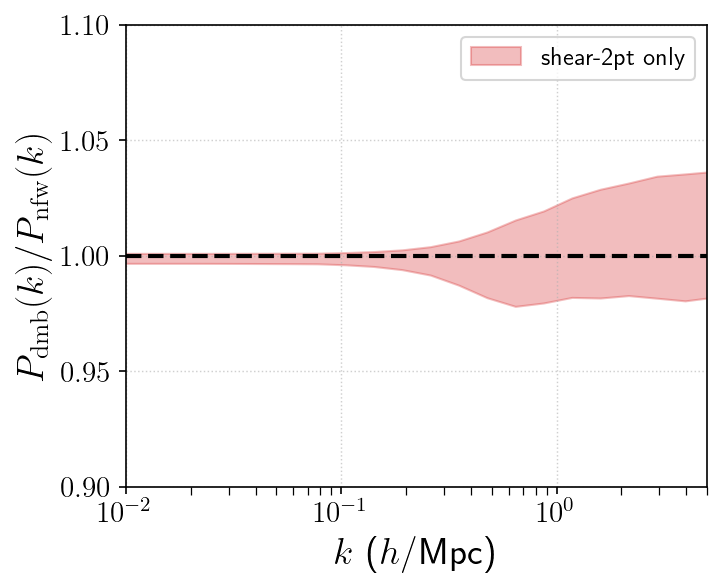

In [31]:
import matplotlib.pyplot as plt

# plt.figure(figsize=(7, 5), dpi=150)
plt.figure(figsize=(5, 4), dpi=150)

# Fill between with transparency for uncertainty
plt.fill_between(Pkz_test.kPk_array, Pmin/Pmm_ratio_fid, Pmax/Pmm_ratio_fid, color='tab:red', alpha=0.3, label='shear-2pt only')
# plt.plot(Pkz_test.kPk_array, Pmm_ratio_fid)
plt.axhline(1.0, ls='--', lw=2, color='black')

# Log scale for x-axis
plt.xscale('log')

# Axis limits
plt.xlim(1e-2, 5)
# plt.ylim(0.6, 1.1)
plt.ylim(0.9, 1.1)

# Axis labels with LaTeX-style formatting
plt.xlabel(r'$k$ ($h$/Mpc)', fontsize=18)
plt.ylabel(r'$P_{\rm dmb}(k)/P_{\rm nfw}(k)$', fontsize=18)

# Improved tick formatting
plt.tick_params(axis='both', which='major', labelsize=14)
plt.tick_params(axis='both', which='minor', labelsize=12, length=4)

plt.legend(fontsize=12, frameon=True, loc='best')
# Grid for better readability
# plt.grid(True, which="both", linestyle=":", linewidth=0.7, alpha=0.6)
plt.grid(True, linestyle=":", linewidth=0.7, alpha=0.6)

# Save figure with high quality (Uncomment if needed)
sdir = '/projects/bdne/spandey3/new_godmax/GODMAX/results/DESxACT/plots/'
# plt.savefig(sdir + 'DeltaP_P_v10_widemuej.pdf', bbox_inches='tight', dpi=300 )
plt.show()




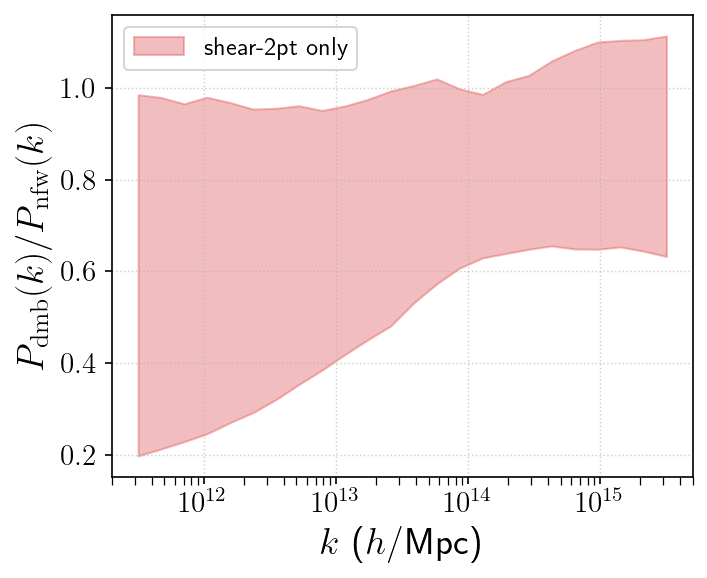

In [27]:
import matplotlib.pyplot as plt

# plt.figure(figsize=(7, 5), dpi=150)
plt.figure(figsize=(5, 4), dpi=150)

plt.fill_between(M_array, Ymin/Y_model_fid, Ymax/Y_model_fid, color='tab:red', alpha=0.3, label='shear-2pt only')
# plt.plot(M_array, Y_model_fid, ls='--', lw=2, color='k')
# plt.axhline(1.0, ls='--', lw=2, color='black')
plt.xscale('log')
# plt.yscale('log')
# plt.xlim(1e-2, 5)
# plt.ylim(0.6, 1.1)

# Axis labels with LaTeX-style formatting
plt.xlabel(r'$k$ ($h$/Mpc)', fontsize=18)
plt.ylabel(r'$P_{\rm dmb}(k)/P_{\rm nfw}(k)$', fontsize=18)

# Improved tick formatting
plt.tick_params(axis='both', which='major', labelsize=14)
plt.tick_params(axis='both', which='minor', labelsize=12, length=4)

plt.legend(fontsize=12, frameon=True, loc='best')
# Grid for better readability
# plt.grid(True, which="both", linestyle=":", linewidth=0.7, alpha=0.6)
plt.grid(True, linestyle=":", linewidth=0.7, alpha=0.6)

# Save figure with high quality (Uncomment if needed)
sdir = '/projects/bdne/spandey3/new_godmax/GODMAX/results/DESxACT/plots/'
# plt.savefig(sdir + 'DeltaP_P_v10_widemuej.pdf', bbox_inches='tight', dpi=300 )
plt.show()




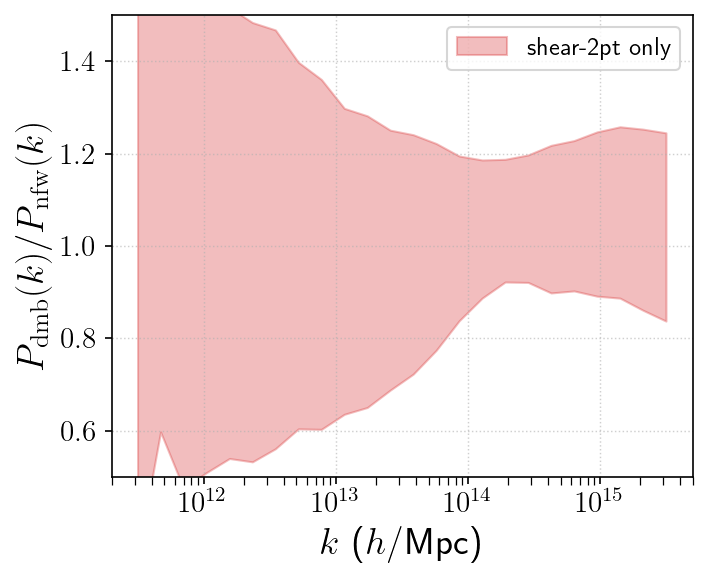

In [28]:
import matplotlib.pyplot as plt

# plt.figure(figsize=(7, 5), dpi=150)
plt.figure(figsize=(5, 4), dpi=150)

plt.fill_between(M_array, fbmin/fb_model_fid, fbmax/fb_model_fid, color='tab:red', alpha=0.3, label='shear-2pt only')
# plt.plot(M_array, fb_model_fid, ls='--', lw=2, color='k')
# plt.axhline(0.048/0.3, ls='--', lw=2, color='black')
plt.xscale('log')
# plt.yscale('log')
# plt.xlim(1e-2, 5)
# plt.ylim(0.6, 1.1)
plt.ylim(0.5, 1.5)
# Axis labels with LaTeX-style formatting
plt.xlabel(r'$k$ ($h$/Mpc)', fontsize=18)
plt.ylabel(r'$P_{\rm dmb}(k)/P_{\rm nfw}(k)$', fontsize=18)

# Improved tick formatting
plt.tick_params(axis='both', which='major', labelsize=14)
plt.tick_params(axis='both', which='minor', labelsize=12, length=4)

plt.legend(fontsize=12, frameon=True, loc='best')
# Grid for better readability
# plt.grid(True, which="both", linestyle=":", linewidth=0.7, alpha=0.6)
plt.grid(True, linestyle=":", linewidth=0.7, alpha=0.6)

# Save figure with high quality (Uncomment if needed)
sdir = '/projects/bdne/spandey3/new_godmax/GODMAX/results/DESxACT/plots/'
# plt.savefig(sdir + 'DeltaP_P_v10_widemuej.pdf', bbox_inches='tight', dpi=300 )
plt.show()




In [142]:
nell = len(l_array_survey)
nell_all = nell * count_all_probes 

nbl = analysis_dict['nz_lens_info_dict']['nbins_lens']
nk = len(analysis_dict['k_array_survey'])
cov_mat_all = np.zeros((nell_all + nbl*nk, nell_all + nbl*nk))
for jp1 in range(len(bin_comb_all_wprobe)):
    for jp2 in range(len(bin_comb_all_wprobe)):
        binwprobe1 = bin_comb_all_wprobe[jp1]
        binwprobe2 = bin_comb_all_wprobe[jp2]        
        probe1 = binwprobe1[0]
        probe2 = binwprobe2[0]
        bin_comb1 = binwprobe1[1]
        bin_comb2 = binwprobe2[1]
        b1, b2 = bin_comb1[0], bin_comb1[1]
        b3, b4 = bin_comb2[0], bin_comb2[1]
        try:
            cov_mat_all[jp1*nell:(jp1+1)*nell, jp2*nell:(jp2+1)*nell] = cov_test.covtot_dict[f'{probe1}_{probe2}'][f'bin_{b1}_{b2}_{b3}_{b4}']
        except:
            cov_mat_all[jp1*nell:(jp1+1)*nell, jp2*nell:(jp2+1)*nell] = cov_test.covtot_dict[f'{probe2}_{probe1}'][f'bin_{b3}_{b4}_{b1}_{b2}']

cov_mat_all[nell_all:(nell_all+nk), nell_all:(nell_all+nk)] = np.clip(Pge_err_z0_wh, 1e-10, 1e10)**2 * np.eye(nk)
cov_mat_all[nell_all+nk:(nell_all+2*nk), nell_all+nk:(nell_all+2*nk)] = np.clip(Pge_err_z1_wh, 1e-10, 1e10)**2 * np.eye(nk)
cov_mat_all[nell_all+2*nk:(nell_all+3*nk), nell_all+2*nk:(nell_all+3*nk)] = np.clip(Pge_err_z2_wh, 1e-10, 1e10)**2 * np.eye(nk)
            

            

In [143]:
cov_test.Cl_result_dict['yy']['bin_' + '0_0'].keys()



dict_keys(['tot_ellsurvey', 'tot_plus_noise_ellsurvey'])

In [144]:
# 
l_array_survey = analysis_dict['l_array_survey']


In [145]:
import interpax
ell_yy_noise, Cl_yy_noise = np.loadtxt(analysis_dict['yy_noise_ell_fname'], unpack = True)
log_Cl_yy_noise_interp = interpax.Interpolator1D(
    jnp.log(ell_yy_noise), jnp.log(jnp.abs(Cl_yy_noise)) + 1e-25, extrap=[Cl_yy_noise[0], Cl_yy_noise[-1]]
)
noise_yy = jnp.exp(log_Cl_yy_noise_interp(jnp.log(l_array_survey)))


In [146]:
ell_yy_noise


array([  80.,   81.,   82., ..., 7977., 7978., 7979.])

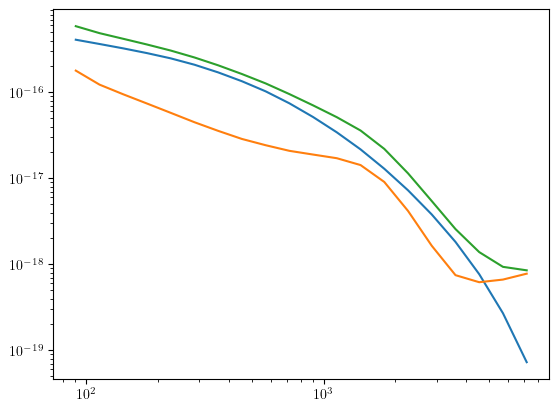

In [147]:
pl.figure()
pl.plot(l_array_survey, cov_test.Cl_result_dict['yy']['bin_' + '0_0']['tot_ellsurvey'])
pl.plot(l_array_survey, noise_yy)
pl.plot(l_array_survey, cov_test.Cl_result_dict['yy']['bin_' + '0_0']['tot_plus_noise_ellsurvey'])
pl.yscale('log')
pl.xscale('log')


/tmp/ipykernel_119711/3287608699.py:4: RuntimeWarning: divide by zero encountered in log
  pl.imshow(np.log(np.abs(cov_mat_all[nell_all:, nell_all:])), cmap='inferno')


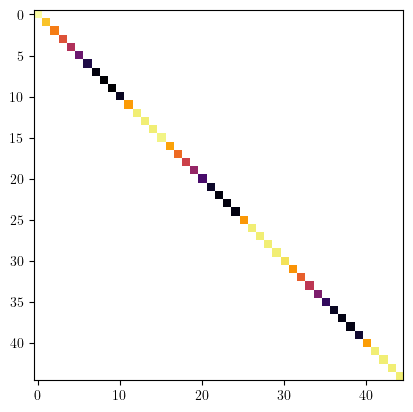

In [148]:
# cov_mat_all
# Pge_err_z0_wh
pl.figure()
pl.imshow(np.log(np.abs(cov_mat_all[nell_all:, nell_all:])), cmap='inferno')


In [149]:
# bin_comb_all_wprobe[:19]
np.diag(cov_mat_all)


array([1.20817015e-27, 6.25225237e-28, 3.30843153e-28, 1.73785431e-28,
       8.87888199e-29, 4.23478417e-29, 1.89273765e-29, 8.13938279e-30,
       3.43920783e-30, 1.43147154e-30, 6.04256572e-31, 2.61210378e-31,
       1.11533231e-31, 4.23235336e-32, 1.37689482e-32, 4.11721011e-33,
       1.22401024e-33, 4.16233742e-34, 1.76886914e-34, 1.01647310e-34,
       1.92497632e-27, 9.29325026e-28, 4.67233955e-28, 2.36239805e-28,
       1.17628247e-28, 5.51702390e-29, 2.43163390e-29, 1.02908748e-29,
       4.25355615e-30, 1.71583424e-30, 6.96780706e-31, 2.89717575e-31,
       1.19691676e-31, 4.43441654e-32, 1.41962614e-32, 4.19747397e-33,
       1.23792844e-33, 4.18660759e-34, 1.77385741e-34, 1.01795687e-34,
       2.83046672e-27, 1.28579388e-27, 6.13347740e-28, 2.96814381e-28,
       1.42609188e-28, 6.53473976e-29, 2.84108280e-29, 1.19234714e-29,
       4.89578416e-30, 1.95737122e-30, 7.83965686e-31, 3.19815310e-31,
       1.29358378e-31, 4.70138246e-32, 1.48218771e-32, 4.32634199e-33,
      

In [150]:
probe_boundaries = np.array([5,15,3,6, 15])
probe_boundaries_cs = np.cumsum(probe_boundaries)
probe_boundaries_center = probe_boundaries_cs - (probe_boundaries/2)
# print(probe_boundaries_cs)
probe_boundaries_edge_right = probe_boundaries_cs
probe_boundaries_edge_left = probe_boundaries_cs - probe_boundaries
ell_edge_left = nell*probe_boundaries_edge_left
ell_edge_right = nell*probe_boundaries_edge_right
probes_all.append('ge')
ell_edge_left = np.append(ell_edge_left, ell_edge_right[-1])
ell_edge_right = np.append(ell_edge_right, ell_edge_right[-1] + 3*nk)




([<matplotlib.axis.YTick at 0xffe5f58be3b0>,
 [Text(0, 50.0, '$\\langle \\kappa y \\rangle$'),
  Text(0, 250.0, '$\\langle \\kappa \\kappa  \\rangle$'),
  Text(0, 430.0, '$\\langle g y \\rangle$'),
  Text(0, 520.0, '$\\langle gg \\rangle$'),
  Text(0, 730.0, '$\\langle g \\kappa \\rangle$'),
  Text(0, 902.5, '$\\langle g e \\rangle$')])

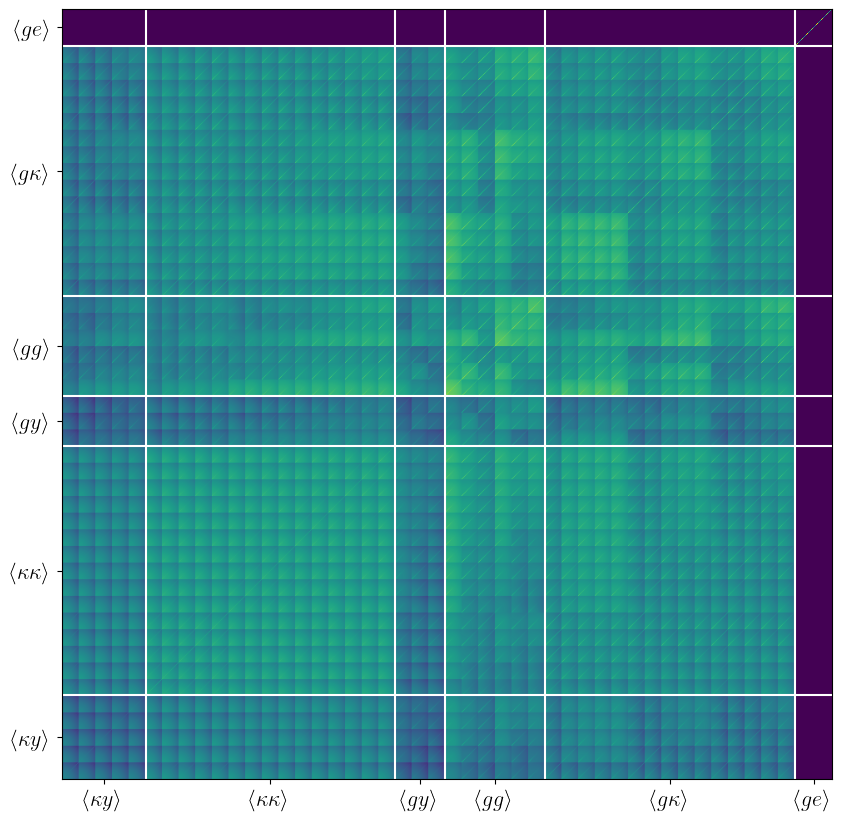

In [151]:
pl.figure(figsize=(10,10))
pl.imshow(np.log(np.abs(cov_mat_all + 1e-70)), origin='lower', vmin=-100, vmax=-20)
pl.axhline(probe_boundaries_cs[0]*nell, color='white')
pl.axhline(probe_boundaries_cs[1]*nell, color='white')
pl.axhline(probe_boundaries_cs[2]*nell, color='white')
pl.axhline(probe_boundaries_cs[3]*nell, color='white')
pl.axhline(probe_boundaries_cs[4]*nell, color='white')

pl.axvline(probe_boundaries_cs[0]*nell, color='white')
pl.axvline(probe_boundaries_cs[1]*nell, color='white')
pl.axvline(probe_boundaries_cs[2]*nell, color='white')
pl.axvline(probe_boundaries_cs[3]*nell, color='white')
pl.axvline(probe_boundaries_cs[4]*nell, color='white')

# write custom text as x-axis labels at a given tick values:
# pl.xticks(probe_boundaries_center*nell, ['ky', 'kk', 'gy', 'gg', 'gk'], fontsize=16)
ticks_loc = np.append(probe_boundaries_center*nell, [probe_boundaries_cs[-1]*nell + 1.5*nk])
pl.xticks(ticks_loc, [r'$\langle \kappa y \rangle$', r'$\langle \kappa \kappa  \rangle$', r'$\langle g y \rangle$', r'$\langle gg \rangle$', r'$\langle g \kappa \rangle$', r'$\langle g e \rangle$'], fontsize=16)
pl.yticks(ticks_loc, [r'$\langle \kappa y \rangle$', r'$\langle \kappa \kappa  \rangle$', r'$\langle g y \rangle$', r'$\langle gg \rangle$', r'$\langle g \kappa \rangle$', r'$\langle g e \rangle$'], fontsize=16)
# pl.imshow(cov_mat_all[1050:,1050:], origin='lower')
# pl.savefig('cov_mat_all_new_v3.pdf', bbox_inches='tight', dpi=300)




In [152]:
# pl.figure(figsize=(10,10))
# pl.imshow(np.log(np.abs(cov_mat_all + 1e-70)), origin='lower', vmin=-100, vmax=-20)
# pl.axhline(probe_boundaries_cs[0]*nell, color='white')
# pl.axhline(probe_boundaries_cs[1]*nell, color='white')
# pl.axhline(probe_boundaries_cs[2]*nell, color='white')
# pl.axhline(probe_boundaries_cs[3]*nell, color='white')
# pl.axhline(probe_boundaries_cs[4]*nell, color='white')

# pl.axvline(probe_boundaries_cs[0]*nell, color='white')
# pl.axvline(probe_boundaries_cs[1]*nell, color='white')
# pl.axvline(probe_boundaries_cs[2]*nell, color='white')
# pl.axvline(probe_boundaries_cs[3]*nell, color='white')
# pl.axvline(probe_boundaries_cs[4]*nell, color='white')

# # write custom text as x-axis labels at a given tick values:
# # pl.xticks(probe_boundaries_center*nell, ['ky', 'kk', 'gy', 'gg', 'gk'], fontsize=16)
# ticks_loc = np.append(probe_boundaries_center*nell, [probe_boundaries_cs[-1]*nell + 1.5*nk])
# pl.xticks(ticks_loc, [r'$\langle \kappa y \rangle$', r'$\langle \kappa \kappa  \rangle$', r'$\langle g y \rangle$', r'$\langle gg \rangle$', r'$\langle g \kappa \rangle$', r'$\langle g e \rangle$'], fontsize=16)
# pl.yticks(ticks_loc, [r'$\langle \kappa y \rangle$', r'$\langle \kappa \kappa  \rangle$', r'$\langle g y \rangle$', r'$\langle gg \rangle$', r'$\langle g \kappa \rangle$', r'$\langle g e \rangle$'], fontsize=16)
# # pl.imshow(cov_mat_all[1050:,1050:], origin='lower')
# # pl.savefig('cov_mat_all_new_v3.pdf', bbox_inches='tight', dpi=300)



In [153]:
# from get_power_spectra import get_power_BCMP
# get_power_test = get_power_BCMP(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict)
from get_Cls import get_Cl

get_power_BCMP_test = get_Cl(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict)



In [154]:
Cl_all = np.zeros((nell_all + nbl*nk))
for jp1 in range(len(bin_comb_all_wprobe)):
    binwprobe1 = bin_comb_all_wprobe[jp1]
    probe1 = binwprobe1[0]
    bin_comb1 = binwprobe1[1]
    b1, b2 = bin_comb1[0], bin_comb1[1]
    Cl_all[jp1*nell:(jp1+1)*nell] = cov_test.Cl_result_dict[f'{probe1}'][f'bin_{b1}_{b2}']['tot_ellsurvey']

Cl_all[nell_all:nell_all+nk] = get_power_BCMP_test.Pge_tot_mat[0,:]
Cl_all[nell_all+nk:nell_all+2*nk] = get_power_BCMP_test.Pge_tot_mat[1,:]
Cl_all[nell_all+2*nk:nell_all+3*nk] = get_power_BCMP_test.Pge_tot_mat[2,:]


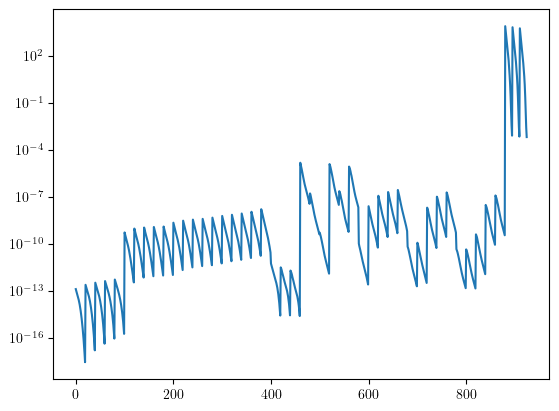

In [155]:
# get_power_test.Pge_tot_array[2,:]
# Cl_all.shape, cov_mat_all.shape
pl.figure()
pl.plot(Cl_all)
pl.yscale('log')



In [156]:
# probes_all


In [157]:
probes_all




['ky', 'kk', 'gy', 'gg', 'gk', 'ge']

In [158]:
# save DV:
saved = {'ell_array':l_array_survey, 'k_array':analysis_dict['k_array_survey'], 
         'Cl_Pk':Cl_all, 'cov_mat':cov_mat_all, 'probes':probes_all, 
         'edges_left':ell_edge_left, 'edges_right':ell_edge_right,
         'bin_comb_all_wprobe':bin_comb_all_wprobe}
# pk.dump(saved, open(abs_path_data + '/pge/DV_fid_Cl_Pk_cov_mthresh_hod_v3.pk','wb'))
pk.dump(saved, open(abs_path_data + '/pge/DV_fid_Cl_Pk_cov_mthresh_hod_v4_symb.pk','wb'))



(850.0, 940.0)

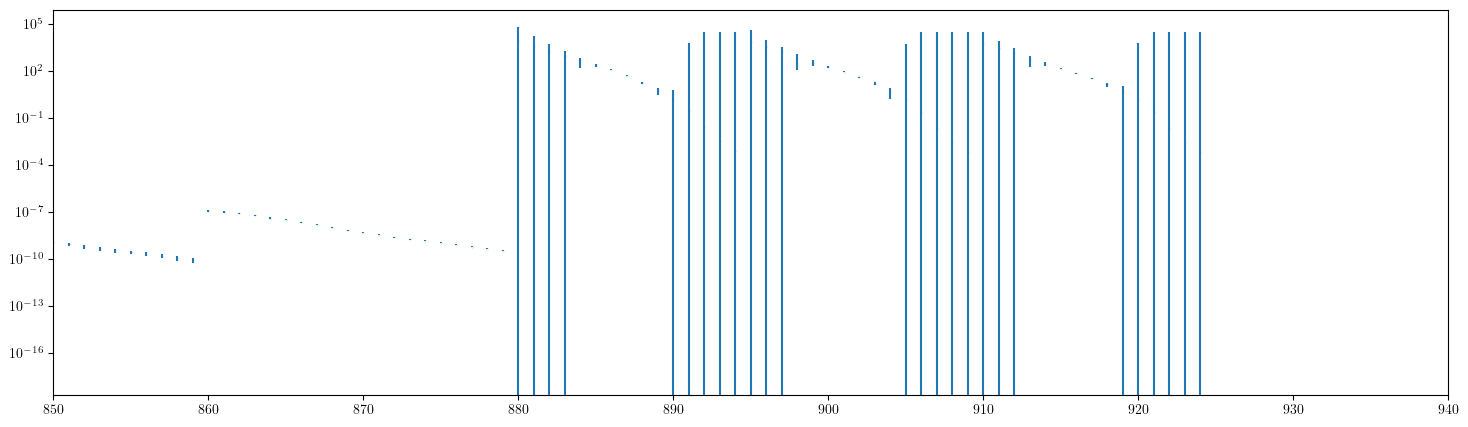

In [163]:
pl.figure(figsize=(18,5))
pl.errorbar(np.arange(nell_all + nbl*nk), Cl_all, yerr=np.sqrt(np.diag(cov_mat_all)), fmt='o', markersize=0.1)
pl.yscale('log')
# pl.xlim(1300,1400)
pl.xlim(850,940)




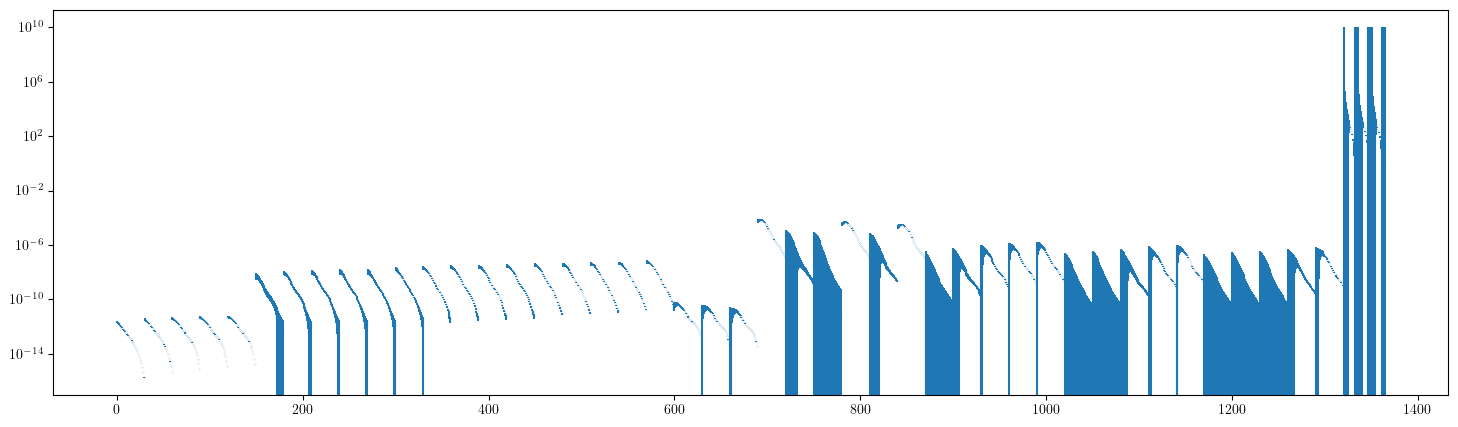

In [21]:
pl.figure(figsize=(18,5))
pl.errorbar(np.arange(nell_all + nbl*nk), Cl_all, yerr=np.sqrt(np.diag(cov_mat_all)), fmt='o', markersize=0.1)
pl.yscale('log')
# pl.xlim(1000,1200)



In [129]:
# cov_test.covtot_dict.keys()
cov_test.Cl_result_dict['gg']['bin_1_1'].keys()


dict_keys(['tot_ellsurvey', 'tot_plus_noise_ellsurvey'])

In [225]:
M_array = jnp.logspace(11, 16, 10)
val = 1e13
jnp.where(M_array > val, 1, 0)   


Array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1], dtype=int64, weak_type=True)

In [227]:
(-1)**1.5

(-1.8369701987210297e-16-1j)

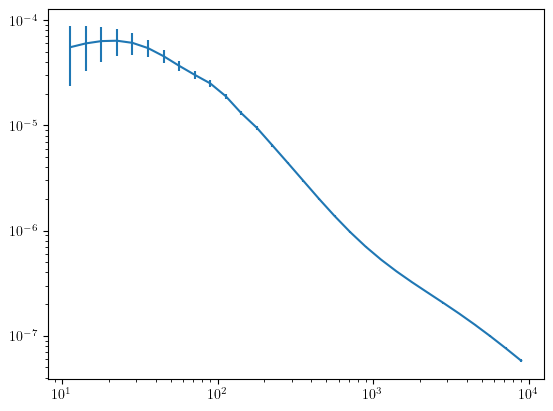

In [130]:
pl.figure()
pl.errorbar(cov_test.Cl_result_dict['l_array_survey'],cov_test.Cl_result_dict['gg']['bin_1_1']['tot_ellsurvey'],np.sqrt(np.diag(cov_test.covtot_dict['gg_gg']['bin_1_1_1_1'])) )
pl.xscale('log')
pl.yscale('log')




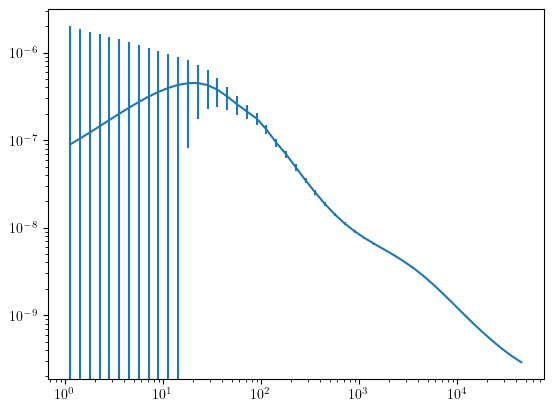

In [ ]:
pl.figure()
pl.errorbar(cov_test.Cl_result_dict['l_array_survey'],cov_test.Cl_result_dict['gk']['bin_1_3']['tot_ellsurvey'],np.sqrt(np.diag(cov_test.covtot_dict['gk_gk']['bin_1_3_1_3'])) )
pl.xscale('log')
pl.yscale('log')




(1e-14, 1e-10)

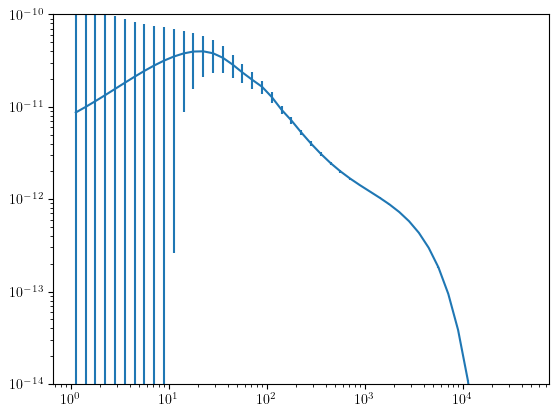

In [52]:
ell = cov_test.Cl_result_dict['l_array_survey']
pl.figure()
pl.errorbar(ell,cov_test.Cl_result_dict['gy']['bin_1_0']['tot_ellsurvey'],np.sqrt(np.diag(cov_test.covtot_dict['gy_gy']['bin_1_0_1_0'])) )
pl.xscale('log')
pl.yscale('log')
pl.ylim(1e-14, 1e-10)




(1e-18, 1e-11)

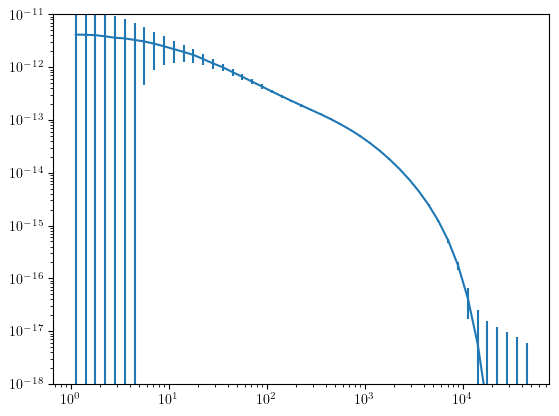

In [54]:
ell = cov_test.Cl_result_dict['l_array_survey']
pl.figure()
pl.errorbar(ell,cov_test.Cl_result_dict['ky']['bin_1_0']['tot_ellsurvey'],np.sqrt(np.diag(cov_test.covtot_dict['ky_ky']['bin_1_0_1_0'])) )
pl.xscale('log')
pl.yscale('log')
pl.ylim(1e-18, 1e-11)




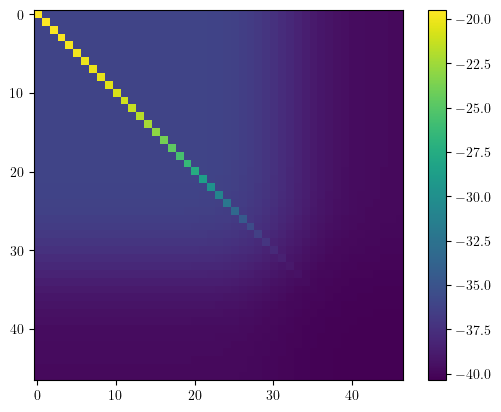

In [48]:
pl.figure()
pl.imshow(np.log(np.abs(cov_test.covtot_dict['gg_gg']['bin_1_1_1_1'])))
pl.colorbar()
pl.show()


